This Notebook is aimed to train an CNN to classify handwriting digits.

## Data and Importing

In [209]:
import sys
import sklearn
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable 
from torch.utils.data import DataLoader, TensorDataset
torch.manual_seed(33)
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
np.random.seed(33)
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

In [210]:
from sklearn.datasets import load_digits
X_full = load_digits().images
y_full = load_digits().target
X_full = X_full[:, None, :, :] # right shape

In [211]:
X_tr=X_full[:1500]
X_ts=X_full[1500:]
y_tr=y_full[:1500]
y_ts=y_full[1500:]

In [212]:
X_tr = torch.tensor(X_tr, dtype=torch.float32)
X_ts = torch.tensor(X_ts, dtype=torch.float32)
y_tr = torch.tensor(y_tr, dtype=torch.long)
y_ts = torch.tensor(y_ts, dtype=torch.long)

In [213]:
# 创建数据加载器
tr_dataset = TensorDataset(X_tr, y_tr)
ts_dataset = TensorDataset(X_ts, y_ts)

In [214]:
tr_loader = DataLoader(tr_dataset, batch_size=32, shuffle=True)
ts_loader = DataLoader(ts_dataset, batch_size=len(ts_dataset), shuffle=False)

## ANN model

In [215]:
class CnnDigitsModel(nn.Module):

    def __init__(self):
        super(CnnDigitsModel, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1) # 输入通道数；输出通道数；核大小；边界填充
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 2 * 2, 64)
        self.fc2 = nn.Linear(64, 10)
        self.relu = nn.ReLU() # 
        self.pool = nn.MaxPool2d(2, 2) # 池化方法
    def forward(self,x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 32  * 2 * 2)  # 展平
        x = self.relu(self.fc1(x)) #全链接
        x = self.fc2(x)
        return x

In [216]:
cnn_digits_model=CnnDigitsModel()
cnn_digits_model.parameters

<bound method Module.parameters of CnnDigitsModel(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)>

In [217]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn_digits_model.parameters(),lr=0.001)

## Train the Model

In [218]:
# 训练模型
num_epochs = 50
tr_losses = []
for epoch in range(num_epochs):
    cnn_digits_model.train()
    running_loss = 0.0
    for X_batch, y_batch in tr_loader:
        outputs = cnn_digits_model(X_batch)
        loss = criterion(outputs, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    # 记录每个 epoch 的平均损失
    epoch_loss = running_loss / len(tr_loader)
    tr_losses.append(epoch_loss)

    print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {running_loss / len(tr_loader):.4f}")

Epoch [1/50], Loss: 1.6860
Epoch [2/50], Loss: 0.4339
Epoch [3/50], Loss: 0.1663
Epoch [4/50], Loss: 0.1091
Epoch [5/50], Loss: 0.0794
Epoch [6/50], Loss: 0.0593
Epoch [7/50], Loss: 0.0539
Epoch [8/50], Loss: 0.0444
Epoch [9/50], Loss: 0.0339
Epoch [10/50], Loss: 0.0224
Epoch [11/50], Loss: 0.0215
Epoch [12/50], Loss: 0.0157
Epoch [13/50], Loss: 0.0159
Epoch [14/50], Loss: 0.0112
Epoch [15/50], Loss: 0.0081
Epoch [16/50], Loss: 0.0066
Epoch [17/50], Loss: 0.0087
Epoch [18/50], Loss: 0.0051
Epoch [19/50], Loss: 0.0029
Epoch [20/50], Loss: 0.0023
Epoch [21/50], Loss: 0.0021
Epoch [22/50], Loss: 0.0019
Epoch [23/50], Loss: 0.0019
Epoch [24/50], Loss: 0.0016
Epoch [25/50], Loss: 0.0015
Epoch [26/50], Loss: 0.0014
Epoch [27/50], Loss: 0.0012
Epoch [28/50], Loss: 0.0012
Epoch [29/50], Loss: 0.0011
Epoch [30/50], Loss: 0.0010
Epoch [31/50], Loss: 0.0009
Epoch [32/50], Loss: 0.0009
Epoch [33/50], Loss: 0.0008
Epoch [34/50], Loss: 0.0008
Epoch [35/50], Loss: 0.0007
Epoch [36/50], Loss: 0.0007
E

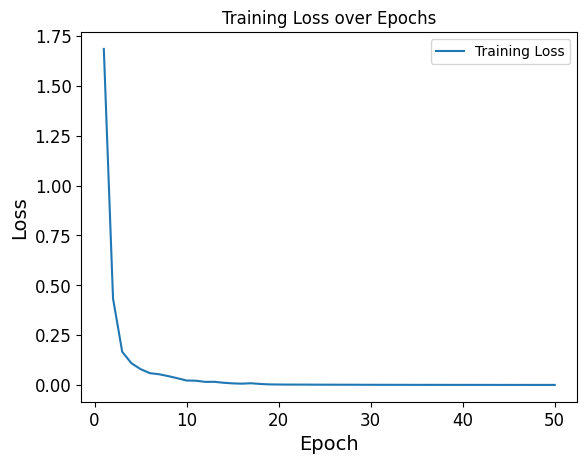

In [219]:
plt.plot(range(1, num_epochs + 1), tr_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.legend()
plt.show()

In [220]:
# 测试模型
cnn_digits_model.eval()
correct = 0
total = 0
with torch.no_grad():
    for X_batch, y_batch in ts_loader:
        outputs = cnn_digits_model(X_batch)
        _, predicted = torch.max(outputs, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

accuracy = correct / total
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 94.61%
